# Unsupervised Learning - Clustering

## Combined Cycle Power Plant Dataset

Pada tahap ini dilakukan proses **unsupervised learning** menggunakan
metode **K-Means Clustering** pada dataset Combined Cycle Power Plant.

Clustering bertujuan untuk mengelompokkan data berdasarkan kemiripan
karakteristik kondisi operasi yang terdapat pada dataset.

Fitur yang digunakan dalam proses clustering adalah:

- **AT** : Ambient Temperature
- **V** : Exhaust Vacuum
- **AP** : Ambient Pressure
- **RH** : Relative Humidity

Variabel **PE (Electrical Power Output)** tidak digunakan dalam pembentukan
cluster dan akan digunakan sebagai variabel pendukung untuk menganalisis
karakteristik hasil clustering.

## 1. Import Library

Pada tahap ini digunakan beberapa library yang dibutuhkan untuk proses
clustering, yaitu Pandas dan NumPy untuk pengolahan data, Matplotlib
untuk visualisasi, serta Scikit-learn untuk preprocessing, K-Means,
evaluasi clustering, dan reduksi dimensi menggunakan PCA.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

print("Import library selesai.")

Import library selesai.


## 2. Load Dataset

Dataset yang digunakan adalah data CCPP yang sudah dibersihkan oleh Data Engineer.

In [66]:
df = pd.read_csv("../data/processed/CCPP_clean.csv")

print("Dataset berhasil dimuat.")
print("Shape:", df.shape)

Dataset berhasil dimuat.
Shape: (9527, 5)


## 3. Melihat Struktur Dataset

Memastikan kolom dan beberapa data awal sebelum proses clustering.

In [67]:
display(df.head())
print("\nKolom:")
print(df.columns.tolist())

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90



Kolom:
['AT', 'V', 'AP', 'RH', 'PE']


## 4. Menentukan Fitur Clustering

Clustering menggunakan variabel sensor `AT`, `V`, `AP`, dan `RH`.
Kolom `PE` tidak digunakan sebagai input clustering.

In [68]:
features = ["AT", "V", "AP", "RH"]
X = df[features].copy()

print("Fitur clustering:", features)
print("Shape fitur:", X.shape)

Fitur clustering: ['AT', 'V', 'AP', 'RH']
Shape fitur: (9527, 4)


## 5. Mengecek Missing Value

Memastikan fitur yang digunakan tidak memiliki missing value.

In [69]:
print(X.isnull().sum())

AT    0
V     0
AP    0
RH    0
dtype: int64


## 6. Load Scaler

Menggunakan `cluster_scaler.pkl` yang sudah disiapkan pada tahap preprocessing.

In [70]:
scaler = joblib.load("../models/cluster_scaler.pkl")
X_scaled = scaler.transform(X)

print("Scaler berhasil dimuat.")
print("Shape data setelah scaling:", X_scaled.shape)

Scaler berhasil dimuat.
Shape data setelah scaling: (9527, 4)


c:\ProgramData\anaconda3\envs\ml_env\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 7. Melihat Hasil Scaling

Melihat ringkasan data setelah standardisasi sebelum masuk ke algoritma clustering.

In [71]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

display(X_scaled_df.describe())

,AT,V,AP,RH
count,9.527000e+03,9.527000e+03,9.527000e+03,9.527000e+03
mean,-5.138700e-16,-2.491039e-16,8.931195e-15,-8.912549e-16
std,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00
min,-2.397664e+00,-2.280800e+00,-3.425311e+00,-3.270746e+00
25%,-8.232429e-01,-9.895770e-01,-6.989788e-01,-6.818733e-01
50%,9.293046e-02,-1.744823e-01,-5.337923e-02,1.139918e-01
75%,8.129728e-01,9.630240e-01,6.671335e-01,7.883377e-01
max,2.344406e+00,2.149405e+00,3.377473e+00,1.836483e+00


## 8. Visualisasi Distribusi Fitur

Melihat distribusi fitur setelah dilakukan standardisasi.

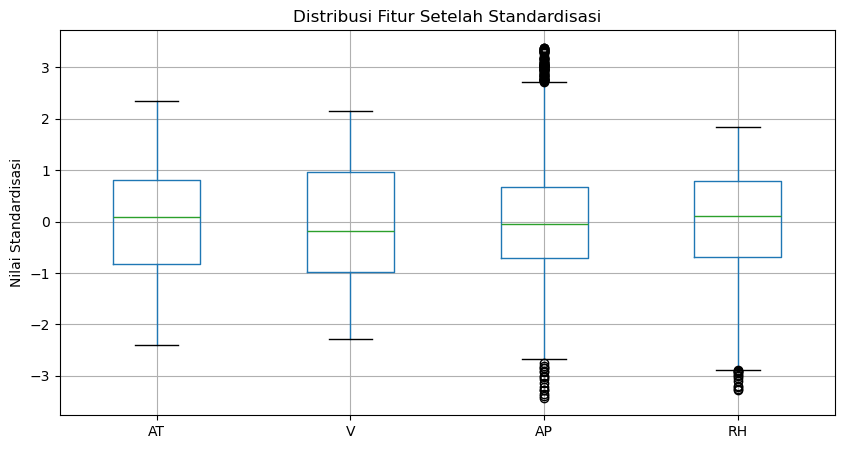

In [72]:
X_scaled_df.boxplot(figsize=(10, 5))
plt.title("Distribusi Fitur Setelah Standardisasi")
plt.ylabel("Nilai Standardisasi")
plt.show()

## 9. K-Means Clustering

K-Means digunakan untuk membagi data menjadi beberapa cluster
berdasarkan kemiripan karakteristik fitur AT, V, AP, dan RH.

Pada tahap awal akan diuji empat nilai K, yaitu 2, 3, 4, dan 5.

In [73]:
k_values = [2, 3, 4, 5]

inertia_scores = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    inertia_scores.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

print("Eksperimen K-Means selesai.")

Eksperimen K-Means selesai.


## 10. Hasil Eksperimen K-Means

Hasil eksperimen dirangkum menggunakan inertia dan Silhouette Score
untuk setiap nilai K.

In [74]:
kmeans_results = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia_scores,
    "Silhouette Score": silhouette_scores
})

kmeans_results

,K,Inertia,Silhouette Score
0,2,20763.733450,0.389646
1,3,16820.302467,0.306773
2,4,13780.515870,0.277154
3,5,11808.953385,0.282668


## 11. Elbow Method

Elbow Method digunakan untuk melihat perubahan inertia ketika jumlah
cluster ditingkatkan.

Nilai inertia yang semakin kecil menunjukkan cluster yang semakin
rapat. Titik "elbow" digunakan sebagai salah satu pertimbangan dalam
menentukan jumlah cluster.

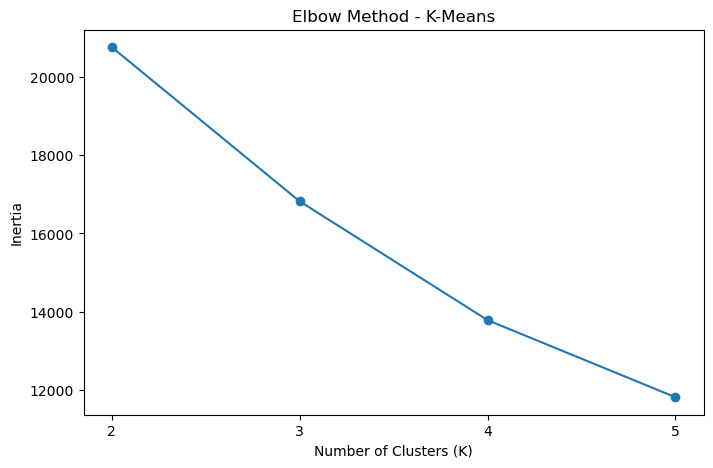

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_scores,
    marker="o"
)

plt.title("Elbow Method - K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

## 12. Silhouette Score

Silhouette Score digunakan untuk mengukur seberapa baik setiap data
berada di dalam cluster-nya dibandingkan dengan cluster lain.

Nilai yang lebih tinggi menunjukkan pemisahan cluster yang lebih baik.

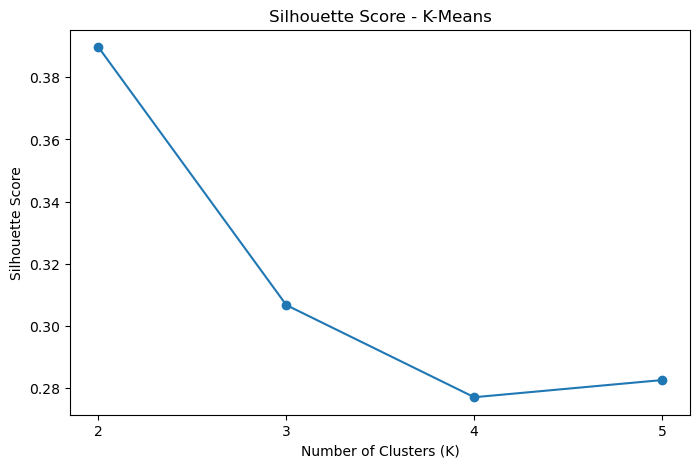

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score - K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

In [77]:
best_k = kmeans_results.loc[
    kmeans_results["Silhouette Score"].idxmax(),
    "K"
]

print("K dengan Silhouette Score tertinggi:", best_k)

K dengan Silhouette Score tertinggi: 2


## 13. K-Means Final

Model final dibuat menggunakan nilai K yang dipilih berdasarkan hasil
eksperimen sebelumnya.

In [78]:
final_kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)

print("K-Means final selesai.")
print("Jumlah cluster:", best_k)

K-Means final selesai.
Jumlah cluster: 2


## 14. Distribusi Cluster

Label cluster ditambahkan ke data untuk melihat jumlah observasi pada
masing-masing cluster.

In [79]:
df_kmeans = df.copy()
df_kmeans["Cluster"] = kmeans_labels

cluster_counts = (
    df_kmeans["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    4705
1    4822
Name: count, dtype: int64

## 15. Profil Cluster

Profil cluster dibuat menggunakan nilai rata-rata setiap fitur
untuk membantu memahami karakteristik masing-masing kelompok.

In [80]:
cluster_profile = (
    df_kmeans
    .groupby("Cluster")[features + ["PE"]]
    .mean()
    .round(2)
)

cluster_profile

,AT,V,AP,RH,PE
Cluster,,,,,
0,13.29,43.74,1016.07,80.11,468.63
1,25.87,64.59,1010.47,66.73,440.39


In [81]:
df_kmeans.to_csv(
    "../data/processed/CCPP_kmeans_result.csv",
    index=False
)

print("Hasil clustering berhasil disimpan.")

Hasil clustering berhasil disimpan.


## 16. Agglomerative Clustering

Agglomerative Clustering merupakan metode hierarchical clustering
yang membangun cluster secara bertahap dengan menggabungkan observasi
berdasarkan kedekatan antar data.

Pada eksperimen ini digunakan Ward linkage.

In [82]:
agglo_k_values = [2, 3, 4, 5]

agglo_results = []

for k in agglo_k_values:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    agglo_results.append({
        "K": k,
        "Silhouette Score": silhouette_score(X_scaled, labels),
        "Davies-Bouldin Score": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled, labels
        )
    })

print("Eksperimen Agglomerative selesai.")

Eksperimen Agglomerative selesai.


## 17. Hasil Eksperimen Agglomerative

Eksperimen dilakukan menggunakan K = 2, 3, 4, dan 5 dengan Ward linkage.

Hasil dibandingkan menggunakan:
- Silhouette Score
- Davies-Bouldin Score
- Calinski-Harabasz Score

In [83]:
agglo_results_df = pd.DataFrame(agglo_results)

display(agglo_results_df)

,K,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,2,0.364801,1.067014,6972.092174
1,3,0.269427,1.401206,4972.016479
2,4,0.221930,1.440995,4558.255891
3,5,0.229027,1.254761,4197.347934


## 18. Silhouette Score

Silhouette Score digunakan untuk melihat kualitas pemisahan antarcluster.
Nilai yang lebih tinggi menunjukkan pemisahan cluster yang lebih baik
menurut metrik ini.

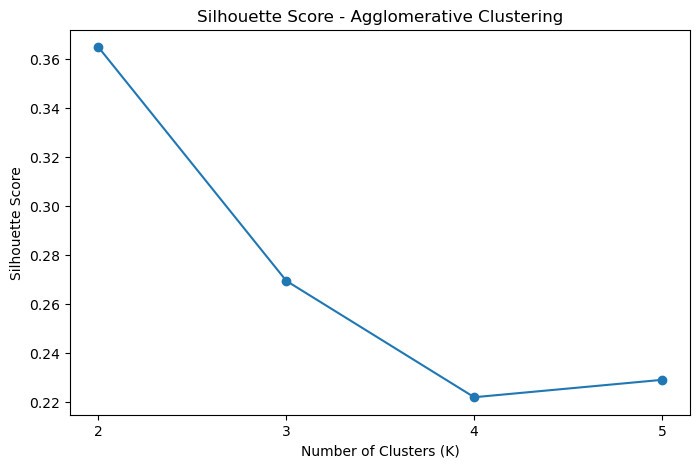

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    agglo_results_df["K"],
    agglo_results_df["Silhouette Score"],
    marker="o"
)

plt.title("Silhouette Score - Agglomerative Clustering")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(agglo_k_values)

plt.show()

## 19. Davies-Bouldin Score

Davies-Bouldin Score digunakan untuk mengevaluasi kemiripan antarcluster.
Nilai yang lebih rendah menunjukkan hasil yang lebih baik menurut metrik ini.

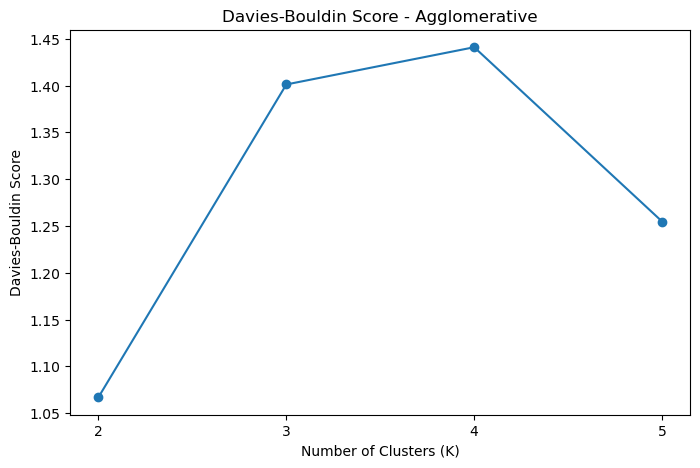

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(
    agglo_results_df["K"],
    agglo_results_df["Davies-Bouldin Score"],
    marker="o"
)

plt.title("Davies-Bouldin Score - Agglomerative")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(agglo_k_values)

plt.show()

## 20. Calinski-Harabasz Score

Calinski-Harabasz Score digunakan untuk melihat kualitas pemisahan
antarcluster. Nilai yang lebih tinggi menunjukkan pemisahan yang lebih baik.

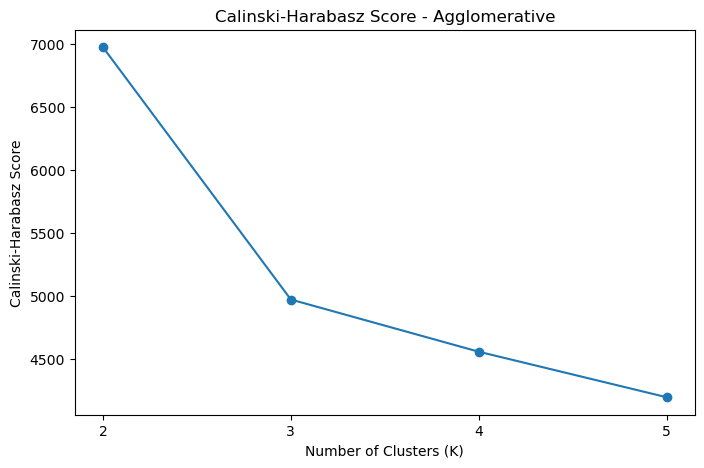

In [86]:
plt.figure(figsize=(8, 5))

plt.plot(
    agglo_results_df["K"],
    agglo_results_df["Calinski-Harabasz Score"],
    marker="o"
)

plt.title("Calinski-Harabasz Score - Agglomerative")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(agglo_k_values)

plt.show()

## 21. Kandidat Jumlah Cluster

Kandidat jumlah cluster ditentukan berdasarkan hasil beberapa metrik.
Silhouette Score digunakan sebagai salah satu acuan, sedangkan
Davies-Bouldin dan Calinski-Harabasz digunakan sebagai pembanding.

In [87]:
agglo_candidate_k = agglo_results_df.loc[
    agglo_results_df["Silhouette Score"].idxmax(),
    "K"
]

print("Kandidat berdasarkan Silhouette Score:", agglo_candidate_k)

Kandidat berdasarkan Silhouette Score: 2


## 22. Model Agglomerative Final

Model final dibuat menggunakan kandidat K yang diperoleh dari
hasil eksperimen sebelumnya.

In [88]:
final_agglo = AgglomerativeClustering(
    n_clusters=int(agglo_candidate_k),
    linkage="ward"
)

agglo_labels = final_agglo.fit_predict(X_scaled)

print("Agglomerative Clustering selesai.")
print("Jumlah cluster:", agglo_candidate_k)

Agglomerative Clustering selesai.
Jumlah cluster: 2


## 23. Distribusi Cluster

Melihat jumlah observasi pada setiap cluster hasil Agglomerative.

In [89]:
df_agglo = df.copy()
df_agglo["Cluster"] = agglo_labels

cluster_counts_agglo = (
    df_agglo["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts_agglo

Cluster
0    5413
1    4114
Name: count, dtype: int64

## 24. Profil Cluster

Profil cluster digunakan untuk memahami karakteristik rata-rata
setiap kelompok berdasarkan variabel input dan Electrical Power Output.

PE hanya digunakan untuk interpretasi, bukan sebagai input clustering.

In [90]:
agglo_profile = (
    df_agglo
    .groupby("Cluster")[features + ["PE"]]
    .mean()
    .round(2)
)

agglo_profile

,AT,V,AP,RH,PE
Cluster,,,,,
0,25.00,63.44,1011.24,67.96,442.24
1,12.62,42.25,1015.87,80.41,470.26


## 25. Menyimpan Hasil Agglomerative

Hasil clustering disimpan agar dapat digunakan pada tahap perbandingan
algoritma.

In [91]:
df_agglo.to_csv(
    "../data/processed/CCPP_agglomerative_result.csv",
    index=False
)

print("Hasil Agglomerative berhasil disimpan.")

Hasil Agglomerative berhasil disimpan.


## 27. DBSCAN Clustering

DBSCAN merupakan algoritma clustering berbasis kepadatan.

Berbeda dengan K-Means dan Agglomerative, DBSCAN tidak membutuhkan
jumlah cluster sebagai input. Parameter utama yang digunakan adalah
`eps` dan `min_samples`.

DBSCAN juga dapat memberikan label `-1` untuk observasi yang dianggap
sebagai noise.

## 28. Menentukan Kandidat `eps` dengan K-Distance Graph

K-distance graph digunakan untuk melihat distribusi jarak ke tetangga
ke-k. Grafik ini membantu menentukan beberapa kandidat nilai `eps`.

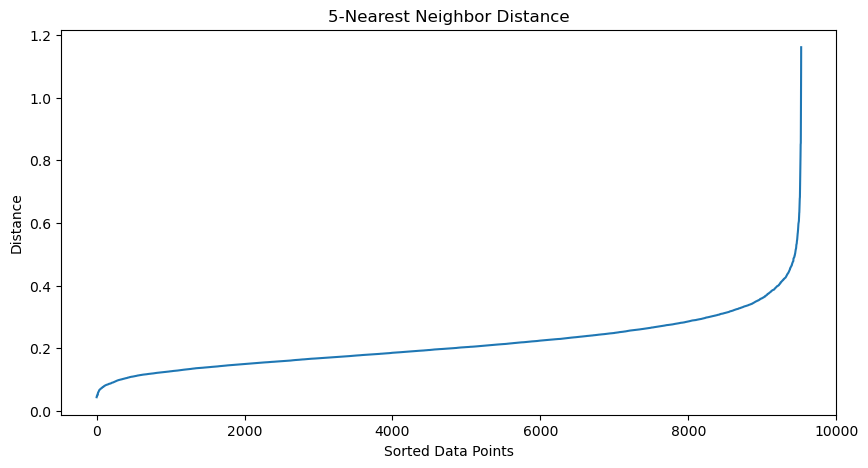

In [92]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
distances, indices = neighbors.fit(X_scaled).kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("5-Nearest Neighbor Distance")
plt.xlabel("Sorted Data Points")
plt.ylabel("Distance")
plt.show()

## 29. Eksperimen Parameter DBSCAN

Lima kombinasi `eps` dan `min_samples` diuji untuk melihat pengaruh
parameter terhadap jumlah cluster dan jumlah noise.

Parameter yang digunakan:
1. eps = 0.5, min_samples = 5
2. eps = 0.7, min_samples = 5
3. eps = 0.9, min_samples = 5
4. eps = 1.1, min_samples = 5
5. eps = 1.3, min_samples = 5

Nilai tersebut digunakan sebagai kandidat awal dan dapat disesuaikan
berdasarkan hasil k-distance graph.

In [93]:
dbscan_params = [
    {"eps": 0.5, "min_samples": 5},
    {"eps": 0.7, "min_samples": 5},
    {"eps": 0.9, "min_samples": 5},
    {"eps": 1.1, "min_samples": 5},
    {"eps": 1.3, "min_samples": 5}
]

print("Jumlah kombinasi parameter:", len(dbscan_params))

Jumlah kombinasi parameter: 5


## 30. Hasil Eksperimen DBSCAN

Setiap kombinasi parameter diuji untuk melihat:
- jumlah cluster
- jumlah noise
- persentase noise
- Silhouette Score
- Davies-Bouldin Score
- Calinski-Harabasz Score

In [94]:
dbscan_results = []

for params in dbscan_params:
    model = DBSCAN(
        eps=params["eps"],
        min_samples=params["min_samples"]
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_pct = n_noise / len(labels) * 100

    if n_clusters >= 2:
        mask = labels != -1

        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        davies_bouldin = davies_bouldin_score(
            X_scaled[mask],
            labels[mask]
        )

        calinski = calinski_harabasz_score(
            X_scaled[mask],
            labels[mask]
        )
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski = np.nan

    dbscan_results.append({
        "eps": params["eps"],
        "min_samples": params["min_samples"],
        "Jumlah Cluster": n_clusters,
        "Jumlah Noise": n_noise,
        "Noise (%)": noise_pct,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Score": davies_bouldin,
        "Calinski-Harabasz Score": calinski
    })

print("Eksperimen DBSCAN selesai.")

Eksperimen DBSCAN selesai.


## 31. Perbandingan Parameter DBSCAN

Tabel berikut digunakan untuk membandingkan hasil dari lima kombinasi
parameter DBSCAN.

In [95]:
dbscan_df = pd.DataFrame(dbscan_results)

display(
    dbscan_df.round(4)
)

,eps,min_samples,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,0.5,5,6,28,0.2939,-0.1587,0.8701,14.0372
1,0.7,5,3,4,0.0420,0.0678,0.8245,12.9046
2,0.9,5,3,0,0.0000,0.0676,0.8248,12.8951
3,1.1,5,1,0,0.0000,NaN,NaN,NaN
4,1.3,5,1,0,0.0000,NaN,NaN,NaN


## 32. Analisis Jumlah Cluster dan Noise

Jumlah cluster dan persentase noise digunakan untuk melihat bagaimana
perubahan `eps` memengaruhi struktur data yang terbentuk.

In [96]:
display(
    dbscan_df[
        [
            "eps",
            "min_samples",
            "Jumlah Cluster",
            "Jumlah Noise",
            "Noise (%)"
        ]
    ]
)

,eps,min_samples,Jumlah Cluster,Jumlah Noise,Noise (%)
0,0.5,5,6,28,0.293902
1,0.7,5,3,4,0.041986
2,0.9,5,3,0,0.000000
3,1.1,5,1,0,0.000000
4,1.3,5,1,0,0.000000


## 33. Silhouette Score DBSCAN

Silhouette Score digunakan untuk mengevaluasi kualitas pemisahan cluster
pada setiap kombinasi parameter yang menghasilkan minimal dua cluster.

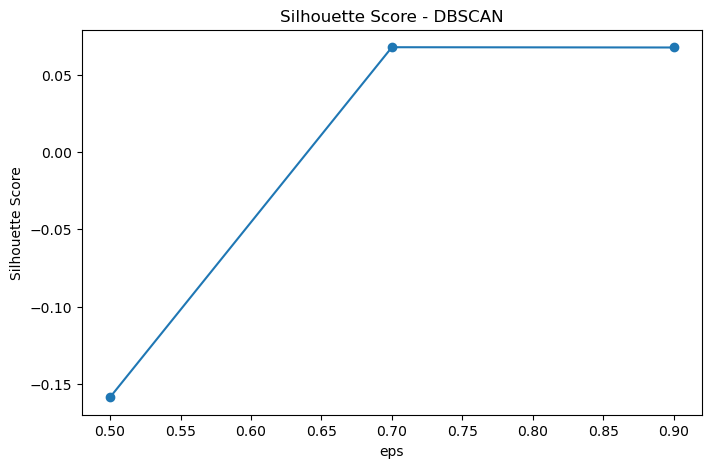

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    dbscan_df["eps"],
    dbscan_df["Silhouette Score"],
    marker="o"
)

plt.title("Silhouette Score - DBSCAN")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")

plt.show()

## 34. Davies-Bouldin Score DBSCAN

Davies-Bouldin Score digunakan sebagai metrik pembanding kualitas cluster.
Nilai yang lebih rendah menunjukkan hasil yang lebih baik menurut metrik ini.

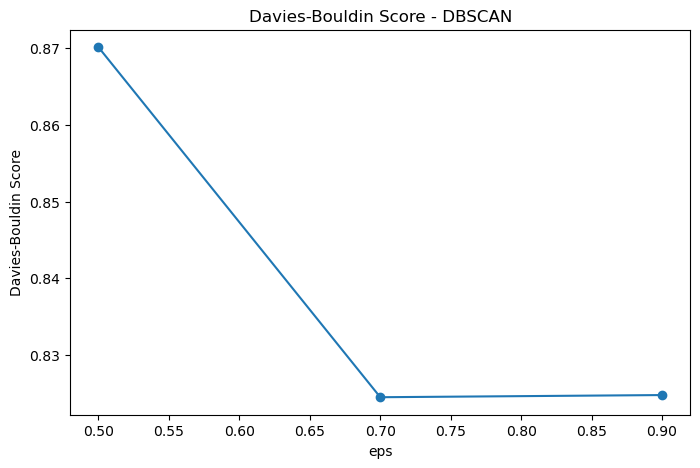

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(
    dbscan_df["eps"],
    dbscan_df["Davies-Bouldin Score"],
    marker="o"
)

plt.title("Davies-Bouldin Score - DBSCAN")
plt.xlabel("eps")
plt.ylabel("Davies-Bouldin Score")

plt.show()

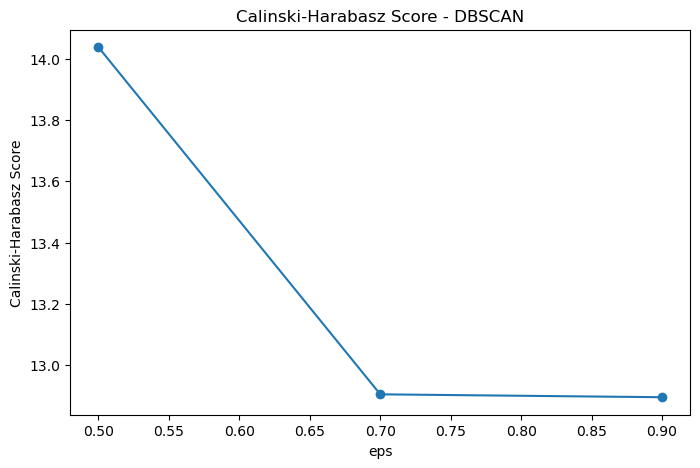

In [99]:
plt.figure(figsize=(8, 5))

plt.plot(
    dbscan_df["eps"],
    dbscan_df["Calinski-Harabasz Score"],
    marker="o"
)

plt.title("Calinski-Harabasz Score - DBSCAN")
plt.xlabel("eps")
plt.ylabel("Calinski-Harabasz Score")

plt.show()

## 36. Persentase Noise

DBSCAN dapat mengidentifikasi observasi yang tidak termasuk ke dalam
cluster sebagai noise dengan label `-1`.

Persentase noise dihitung untuk setiap kombinasi parameter.

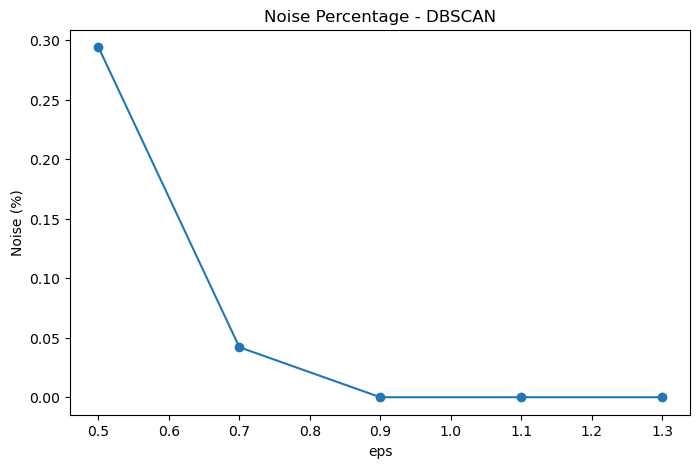

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(
    dbscan_df["eps"],
    dbscan_df["Noise (%)"],
    marker="o"
)

plt.title("Noise Percentage - DBSCAN")
plt.xlabel("eps")
plt.ylabel("Noise (%)")

plt.show()

## 37. Kandidat Parameter DBSCAN

Kombinasi parameter dengan minimal dua cluster dibandingkan menggunakan
seluruh metrik evaluasi dan persentase noise.

Pemilihan parameter final dilakukan setelah mempertimbangkan kualitas
cluster dan jumlah noise secara bersamaan.

In [101]:
dbscan_candidates = dbscan_df[
    dbscan_df["Jumlah Cluster"] >= 2
].copy()

display(
    dbscan_candidates.round(4)
)

,eps,min_samples,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,0.5,5,6,28,0.2939,-0.1587,0.8701,14.0372
1,0.7,5,3,4,0.0420,0.0678,0.8245,12.9046
2,0.9,5,3,0,0.0000,0.0676,0.8248,12.8951


## 37. Model Final DBSCAN

Berdasarkan hasil eksperimen lima kombinasi parameter, konfigurasi
`eps=0.7` dan `min_samples=5` digunakan sebagai kandidat model final.

Konfigurasi ini menghasilkan 3 cluster dengan persentase noise yang
rendah serta nilai evaluasi yang dapat dibandingkan dengan algoritma
clustering lainnya.

In [102]:
BEST_EPS = 0.7
BEST_MIN_SAMPLES = 5

dbscan_final = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

dbscan_labels = dbscan_final.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = np.sum(dbscan_labels == -1)
noise_pct_db = n_noise_db / len(dbscan_labels) * 100

mask_db = dbscan_labels != -1

sil_db = silhouette_score(
    X_scaled[mask_db],
    dbscan_labels[mask_db]
)

db_db = davies_bouldin_score(
    X_scaled[mask_db],
    dbscan_labels[mask_db]
)

ch_db = calinski_harabasz_score(
    X_scaled[mask_db],
    dbscan_labels[mask_db]
)

print(f"DBSCAN final: eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}")
print(f"Jumlah cluster : {n_clusters_db}")
print(f"Jumlah noise   : {n_noise_db}")
print(f"Noise (%)      : {noise_pct_db:.4f}")
print(f"Silhouette     : {sil_db:.4f}")
print(f"Davies-Bouldin : {db_db:.4f}")
print(f"Calinski-Harabasz : {ch_db:.4f}")

DBSCAN final: eps=0.7, min_samples=5
Jumlah cluster : 3
Jumlah noise   : 4
Noise (%)      : 0.0420
Silhouette     : 0.0678
Davies-Bouldin : 0.8245
Calinski-Harabasz : 12.9046


### Distribusi Cluster DBSCAN

Distribusi cluster digunakan untuk melihat jumlah observasi pada setiap
cluster yang terbentuk oleh model final DBSCAN.

In [103]:
dbscan_distribution = pd.Series(
    dbscan_labels,
    name="Cluster"
).value_counts().sort_index()

display(dbscan_distribution)

Cluster
-1       4
 0    9510
 1       7
 2       6
Name: count, dtype: int64

## 38. Profil Cluster DBSCAN

Profil cluster digunakan untuk melihat karakteristik rata-rata variabel
sensor dan target `PE` pada masing-masing cluster.

Variabel `PE` tidak digunakan sebagai input clustering, tetapi dapat
digunakan pada tahap interpretasi untuk melihat perbedaan output
kelistrikan antar cluster.

In [105]:
df_dbscan = df.copy()
df_dbscan["cluster_dbscan"] = dbscan_labels

dbscan_profile = (
    df_dbscan
    .groupby("cluster_dbscan")[["AT", "V", "AP", "RH", "PE"]]
    .mean()
    .round(2)
)

display(dbscan_profile)

,AT,V,AP,RH,PE
cluster_dbscan,,,,,
-1,21.87,42.22,1002.64,75.23,447.74
0,19.67,54.34,1013.25,73.32,454.32
1,11.14,25.36,1009.04,97.37,470.40
2,15.52,25.88,1009.33,70.65,463.36


### Distribusi Observasi DBSCAN

Distribusi cluster digunakan untuk melihat ukuran masing-masing cluster,
termasuk observasi yang diberi label `-1` sebagai noise.

In [106]:
dbscan_size = (
    df_dbscan["cluster_dbscan"]
    .value_counts()
    .sort_index()
    .rename("Jumlah Data")
    .to_frame()
)

dbscan_size["Persentase (%)"] = (
    dbscan_size["Jumlah Data"] /
    len(df_dbscan) * 100
).round(4)

display(dbscan_size)

,Jumlah Data,Persentase (%)
cluster_dbscan,,
-1,4,0.0420
0,9510,99.8216
1,7,0.0735
2,6,0.0630


## 39. PCA untuk Visualisasi Clustering

Principal Component Analysis (PCA) digunakan untuk mereduksi dimensi
fitur clustering menjadi representasi yang lebih sederhana.

PCA digunakan untuk visualisasi dan tidak menggantikan fitur asli yang
digunakan oleh algoritma clustering.

In [107]:
from sklearn.decomposition import PCA

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance = pd.DataFrame({
    "Komponen": range(1, len(explained_variance) + 1),
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

display(pca_variance.round(2))

,Komponen,Explained Variance (%),Cumulative Variance (%)
0,1,61.02,61.02
1,2,22.68,83.70
2,3,13.73,97.43
3,4,2.57,100.00


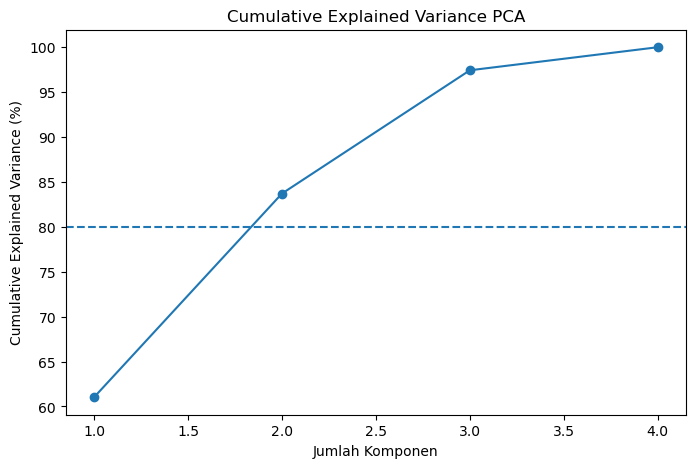

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(80, linestyle="--")

plt.title("Cumulative Explained Variance PCA")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance (%)")

plt.show()

In [109]:
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(
    f"Jumlah komponen untuk mencapai >=80% variance: "
    f"{n_components_80}"
)

print(
    f"Explained variance kumulatif: "
    f"{cumulative_variance[n_components_80 - 1] * 100:.2f}%"
)

Jumlah komponen untuk mencapai >=80% variance: 2
Explained variance kumulatif: 83.70%


## 40. PCA 2D untuk Visualisasi Clustering

Berdasarkan hasil PCA, dua komponen utama sudah mampu menjelaskan
83.70% variasi data.

Oleh karena itu, PC1 dan PC2 digunakan sebagai representasi dua dimensi
untuk memvisualisasikan hasil clustering.

In [110]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(
    f"Explained variance PC1 + PC2: "
    f"{pca_2d.explained_variance_ratio_.sum() * 100:.2f}%"
)

display(pca_df.head())

Explained variance PC1 + PC2: 83.70%


,PC1,PC2
0,-1.674603,-1.256847
1,0.746539,-1.444550
2,-2.275355,1.067552
3,0.350597,0.513116
4,-1.805146,1.563537


## 41. Label Clustering untuk Visualisasi

Hasil clustering dari tiga algoritma digunakan sebagai label pada ruang
PCA dua dimensi.

Konfigurasi yang digunakan:
- K-Means: K = 2
- Agglomerative: K = 2 dengan Ward linkage
- DBSCAN: eps = 0.7 dan min_samples = 5

In [111]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels_pca = kmeans_final.fit_predict(X_scaled)

agglo_final = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agglo_labels_pca = agglo_final.fit_predict(X_scaled)

dbscan_final = DBSCAN(
    eps=0.7,
    min_samples=5
)

dbscan_labels_pca = dbscan_final.fit_predict(X_scaled)

pca_df["K-Means"] = kmeans_labels_pca
pca_df["Agglomerative"] = agglo_labels_pca
pca_df["DBSCAN"] = dbscan_labels_pca

display(pca_df.head())

,PC1,PC2,K-Means,Agglomerative,DBSCAN
0,-1.674603,-1.256847,0,1,0
1,0.746539,-1.444550,1,0,0
2,-2.275355,1.067552,0,1,0
3,0.350597,0.513116,1,0,0
4,-1.805146,1.563537,0,1,0


### Visualisasi K-Means pada Ruang PCA

Visualisasi ini menunjukkan persebaran dua cluster K-Means berdasarkan
PC1 dan PC2.

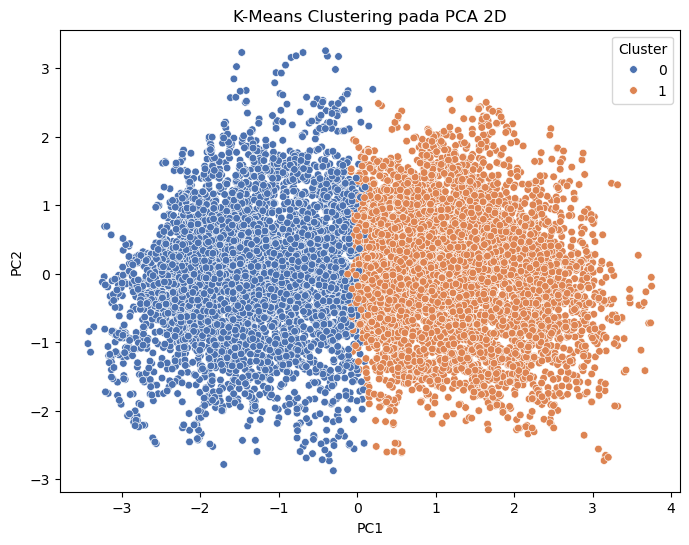

In [112]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="K-Means",
    palette="deep",
    s=30
)

plt.title("K-Means Clustering pada PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

### Visualisasi Agglomerative pada Ruang PCA

Visualisasi ini menunjukkan persebaran cluster Agglomerative pada
ruang dua dimensi hasil PCA.

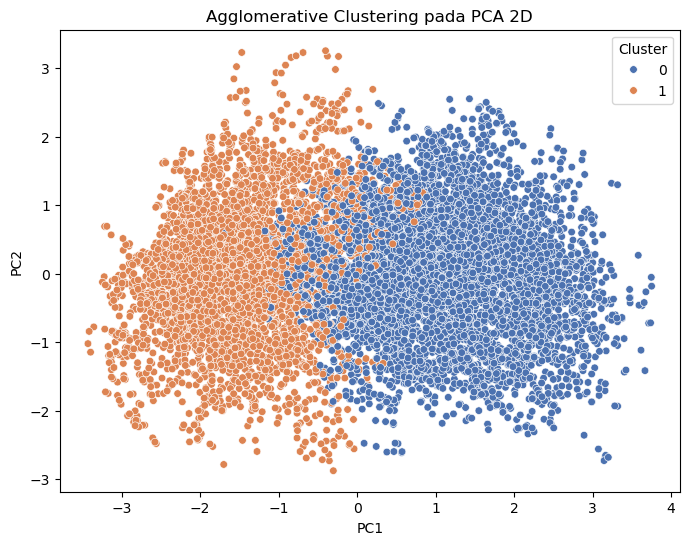

In [113]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Agglomerative",
    palette="deep",
    s=30
)

plt.title("Agglomerative Clustering pada PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

### Visualisasi DBSCAN pada Ruang PCA

Pada DBSCAN, label `-1` menunjukkan observasi yang dianggap sebagai
noise.

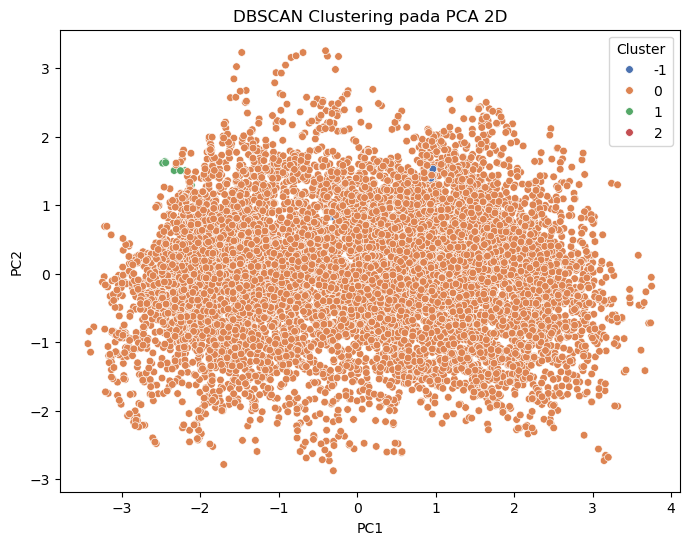

In [114]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="deep",
    s=30
)

plt.title("DBSCAN Clustering pada PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

## 42. Interpretasi Visualisasi PCA

Dua komponen PCA menjelaskan 83.70% variasi data sehingga dapat
digunakan sebagai representasi dua dimensi untuk visualisasi.

Visualisasi PCA digunakan untuk melihat persebaran dan pemisahan cluster
secara visual. Hasil visualisasi perlu dibaca bersama dengan metrik
evaluasi clustering karena proyeksi ke dua dimensi tidak sepenuhnya
merepresentasikan ruang fitur asli.

## 43. Perbandingan Final Algoritma Clustering

Hasil akhir K-Means, Agglomerative Clustering, dan DBSCAN dibandingkan
berdasarkan jumlah cluster, Silhouette Score, Davies-Bouldin Score,
Calinski-Harabasz Score, dan persentase noise.

Perbandingan ini digunakan untuk melihat karakteristik hasil dari setiap
algoritma pada dataset CCPP.

In [115]:
comparison_df = pd.DataFrame([
    {
        "Algoritma": "K-Means",
        "Parameter": "K=2",
        "Jumlah Cluster": 2,
        "Silhouette Score": silhouette_score(
            X_scaled, kmeans_labels_pca
        ),
        "Davies-Bouldin Score": davies_bouldin_score(
            X_scaled, kmeans_labels_pca
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled, kmeans_labels_pca
        ),
        "Noise (%)": 0.0
    },
    {
        "Algoritma": "Agglomerative",
        "Parameter": "K=2, Ward",
        "Jumlah Cluster": 2,
        "Silhouette Score": silhouette_score(
            X_scaled, agglo_labels_pca
        ),
        "Davies-Bouldin Score": davies_bouldin_score(
            X_scaled, agglo_labels_pca
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled, agglo_labels_pca
        ),
        "Noise (%)": 0.0
    },
    {
        "Algoritma": "DBSCAN",
        "Parameter": "eps=0.7, min_samples=5",
        "Jumlah Cluster": 3,
        "Silhouette Score": sil_db,
        "Davies-Bouldin Score": db_db,
        "Calinski-Harabasz Score": ch_db,
        "Noise (%)": noise_pct_db
    }
])

display(comparison_df.round(4))

,Algoritma,Parameter,Jumlah Cluster,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score,Noise (%)
0,K-Means,K=2,2,0.3896,1.0173,7956.4008,0.000
1,Agglomerative,"K=2, Ward",2,0.3648,1.0670,6972.0922,0.000
2,DBSCAN,"eps=0.7, min_samples=5",3,0.0678,0.8245,12.9046,0.042


## 44. Menyimpan Hasil Perbandingan

Tabel perbandingan hasil clustering disimpan sebagai file CSV agar dapat
digunakan kembali untuk dokumentasi, laporan, dan integrasi proyek.

In [116]:
comparison_df.to_csv(
    "../data/processed/CCPP_clustering_comparison.csv",
    index=False
)

print("Hasil perbandingan berhasil disimpan.")

Hasil perbandingan berhasil disimpan.


## 45. Menyimpan Label Clustering dan PCA

Label dari ketiga algoritma serta koordinat PCA 2D disimpan bersama
dataset untuk memudahkan analisis lanjutan dan integrasi dengan bagian
proyek lainnya.

In [117]:
clustering_result = df.copy()

clustering_result["KMeans_Cluster"] = kmeans_labels_pca
clustering_result["Agglomerative_Cluster"] = agglo_labels_pca
clustering_result["DBSCAN_Cluster"] = dbscan_labels_pca
clustering_result["PC1"] = X_pca[:, 0]
clustering_result["PC2"] = X_pca[:, 1]

clustering_result.to_csv(
    "../data/processed/CCPP_clustering_result.csv",
    index=False
)

print("Hasil clustering dan PCA berhasil disimpan.")

Hasil clustering dan PCA berhasil disimpan.


## 46. Kesimpulan Clustering

Analisis clustering pada dataset CCPP dilakukan menggunakan tiga
algoritma, yaitu K-Means, Agglomerative Clustering dengan Ward linkage,
dan DBSCAN.

K-Means dan Agglomerative diuji menggunakan K=2 sampai K=5, sedangkan
DBSCAN diuji menggunakan lima kombinasi parameter `eps` dan
`min_samples`.

Evaluasi dilakukan menggunakan Silhouette Score, Davies-Bouldin Score,
Calinski-Harabasz Score, serta persentase noise untuk DBSCAN.

Hasil PCA menunjukkan bahwa dua komponen utama mampu menjelaskan
83.70% variasi data sehingga PC1 dan PC2 digunakan untuk visualisasi
hasil clustering.

Hasil akhir setiap algoritma kemudian dibandingkan berdasarkan metrik
evaluasi dan karakteristik distribusi cluster.

## 47. Export Model K-Means

Model K-Means final disimpan dalam format `.pkl` agar dapat digunakan
kembali oleh aplikasi tanpa melakukan proses training ulang.

In [118]:
import joblib

kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_model.fit(X_scaled)

joblib.dump(
    kmeans_model,
    "../models/kmeans_clustering.pkl"
)

print("Model K-Means berhasil disimpan.")

Model K-Means berhasil disimpan.


### Verifikasi Model Hasil Export

Model yang telah diekspor dimuat kembali untuk memastikan model dapat
digunakan untuk menghasilkan prediksi cluster.

In [119]:
loaded_kmeans = joblib.load(
    "../models/kmeans_clustering.pkl"
)

test_labels = loaded_kmeans.predict(X_scaled[:10])

print("Prediksi 10 data pertama:")
print(test_labels)

Prediksi 10 data pertama:
[0 1 0 1 0 1 0 0 0 0]
